Астромтерическая калибровка снимка с помощью линейной модели

In [1]:
from math import *
import numpy as np

import pandas as pd
import requests
import io

from astropy.io import fits
from astropy.wcs import WCS
from astropy.time import Time
from astropy.time import TimeDelta

from scipy.optimize import curve_fit

from astropy import units as u
from astropy.coordinates import SkyCoord

import glob
import os
import re

import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
rgray = matplotlib.colormaps['gray'].reversed()


In [2]:
# Ниже будет пример работы с одним из файлов в данном списке
filename = 'Fredschaaf_R.fits'
hdul = fits.open(filename)
img = (hdul[0].data).astype(float) # считываем кадр в переменную img
h, w = np.shape(img)# размеры изображения в пикселях по вертикали и горизонтали

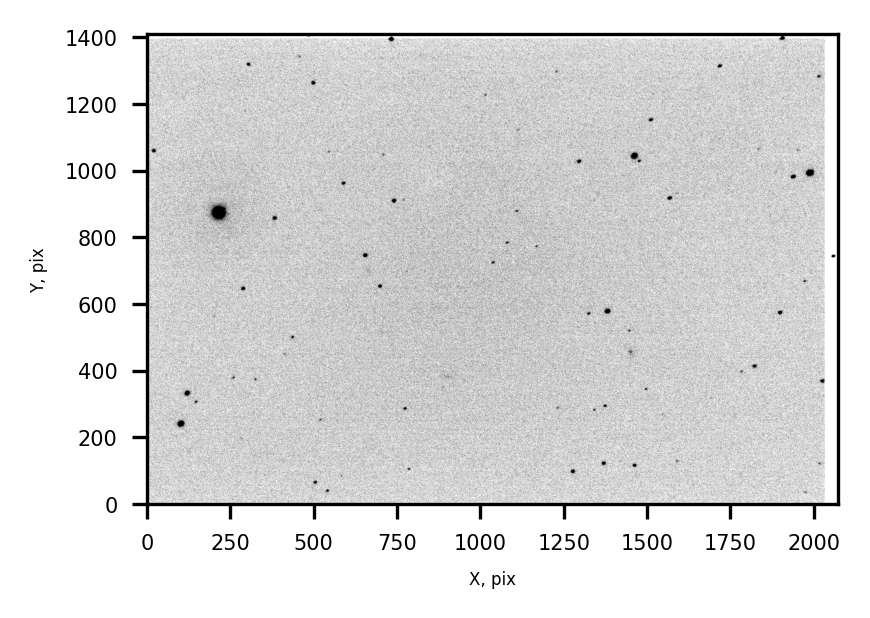

In [5]:

ap =10 # размер апертуры (кружок вокруг звезды)
cf1,cf2 = 0.1,0.5 # определяет окно значений отсчетов, которые будут отрисованы (смотри plt.imshow дальше в этом блоке) 

fig, ax = plt.subplots(figsize=(3.0,3.0), dpi=300)
ax.xaxis.set_tick_params(labelsize=5)
ax.yaxis.set_tick_params(labelsize=5)
plt.xlabel('X, pix', fontsize = 4)
plt.ylabel('Y, pix', fontsize=4) 
plt.imshow(img, vmin=np.median(img)- cf1*np.std(img) ,
           vmax=np.median(img)  + cf2*np.std(img), origin='lower', cmap=rgray) 
plt.tight_layout()

In [7]:
t = Time(hdul[0].header['DATE-OBS'], format='isot') # момент начала съемки
t+=TimeDelta(float(hdul[0].header['EXPTIME']), format='sec')/2 # добавление к начальному моменту половины времени накопления
# То есть t теперь - это центральный момент экспозиции. Потом для него надо будет считать эфемериды 
JD = float(t.copy(format='jd').value) # Юлианская дата для центрального момента
yr = float(t.copy(format='jyear').value) # Юлианский год для центрального момента (нужен для учета собственных движений звезд)

RAc,DECc = hdul[0].header['CRVAL1'],hdul[0].header['CRVAL2'] # экваториальные координаты геометрического центра кадра
# потом эти RAc,DECc будут нужны и для выборки из Gaia, и для расчета тангенциальных координат при калибровке снимка
limmag1,limmag2 = 5.0,16.5 # диапазон блеска для опорных звезд
fov = 0.4# это размер области в градусах

In [8]:
# выборка данных из Gaia DR3 http://sfa.puldb.ru:9810
#response = requests.get(f'http://192.168.30.9:8100?cmd=box&ra={RAc}&dec={DECc}&fov={fov}')
response = requests.get(f'http://sfa.puldb.ru:9810?cmd=box&ra={RAc}&dec={DECc}&fov={fov}')
raw_data = response.content
df = pd.read_csv(io.StringIO(raw_data.decode('utf-8')))
# В последнее время сбои при выборки с родных серверов Gaia стали частыми. 
# Поэтому тут реализована выборка из нашей локальной версии Gaia, размещенной на нашем сервере
# df - это табличка (датафрейм в формате pandas)
df

,solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,...,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot
0,1636148068921376768,Gaia DR3 31629346053610624,31629346053610624,1599974100,2016.0,41.903047,0.451910,12.880628,0.439945,1.137502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1636148068921376768,Gaia DR3 31629414773730560,31629414773730560,1777394263,2016.0,41.872217,0.161349,12.868751,0.143365,0.765060,...,0.6221,0.5860,0.6534,0.4335,0.4081,0.4555,0.2445,0.2304,0.2563,MARCS
2,1636148068921376768,Gaia DR3 31629552212683136,31629552212683136,1049513423,2016.0,41.886017,0.028727,12.885694,0.026467,4.018940,...,0.5700,0.5322,0.6893,0.4082,0.3807,0.4956,0.2227,0.2080,0.2690,PHOENIX
3,1636148068921376768,Gaia DR3 31629552212781568,31629552212781568,428592119,2016.0,41.882581,0.759474,12.881952,0.737778,3.509929,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1636148068921376768,Gaia DR3 31630372551022336,31630372551022336,1215007903,2016.0,41.873109,0.089676,12.908203,0.090645,0.030519,...,0.0096,0.0021,0.0238,0.0080,0.0017,0.0197,0.0043,0.0009,0.0108,MARCS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560,1636148068921376768,Gaia DR3 31856322190395648,31856322190395648,1533700374,2016.0,41.912451,0.489880,13.250178,0.524451,0.531413,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561,1636148068921376768,Gaia DR3 31856360845896320,31856360845896320,1065784707,2016.0,41.890264,0.116716,13.242398,0.109311,3.751342,...,0.3899,0.3802,0.3987,0.3334,0.3249,0.3409,0.1806,0.1761,0.1848,A
562,1636148068921376768,Gaia DR3 31856390910098304,31856390910098304,475109595,2016.0,41.906601,0.891415,13.259933,0.769469,-1.213972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
563,1636148068921376768,Gaia DR3 31856704442495104,31856704442495104,1664120073,2016.0,41.931502,3.016929,13.255391,2.910636,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# стандартный набор - функции для расчета углов, тангенциальных координат (и обратное преобразование)
def angular_distance(ra,dec,RA,DEC):
    return acos(sin(dec)*sin(DEC)+cos(dec)*cos(DEC)*cos(ra-RA))

def tangential_coordinates(ra,dec,RA,DEC):
    ksi = cos(dec)*sin(ra-RA)/(sin(dec)*sin(DEC)+cos(dec)*cos(DEC)*cos(ra-RA))
    eta = (sin(dec)*cos(DEC)-cos(dec)*sin(DEC)*cos(ra-RA))/(sin(dec)*sin(DEC)+cos(dec)*cos(DEC)*cos(ra-RA))
    return ksi,eta

def equatorial_coordinates(ksi,eta,RA,Dec):
    x,y,z = np.dot(np.array([[-sin(RA),-cos(RA) * sin(Dec),cos(RA) * cos(Dec)],
                             [cos(RA),-sin(RA) * sin(Dec),sin(RA) * cos(Dec)],
                             [0,cos(Dec),sin(Dec)]]),
                   np.array([ksi,eta,1]))/sqrt(1+ksi*ksi+eta*eta)
    ra = atan2(y,x)
    dec = atan2(z,sqrt(x*x+y*y))
    if(ra<0):
        ra+=2*pi
    return ra,dec
# функция, которая работает с таблицей, полученной в результате выборки из Gaia
# производится учет собственных движений и возвращаются три массива (два для координат и один для оценок блеска звезд)
def get_Gaia_data(yr, lm1,lm2, gdf):
    ra,dec,gmag = [],[],[]
    for index, row in gdf.iterrows():
        G = row['phot_g_mean_mag']
        if (not isnan(G)) and (lm1<G<lm2):
            ra0,dec0,pmra,pmdec,ep = radians(row['ra']),radians(row['dec']),\
                radians(row['pmra']/3600000.0),\
                radians(row['pmdec']/3600000.0),\
                row['ref_epoch']
            if not isnan(pmra):
                alpha,delta = np.degrees(equatorial_coordinates(pmra*(yr-ep),pmdec*(yr-ep),ra0,dec0))
                ra.append(alpha)
                dec.append(delta)
                gmag.append(G)
    return np.array(ra),np.array(dec),np.array(gmag)

In [10]:
ra,dec,gmag = get_Gaia_data(yr,limmag1,limmag2, df) # после вызова этой функции у нас в руках экваториальные координаты с учетом собственных движений 


In [11]:
W = WCS(hdul[0].header)#заголовок WCS

Set MJD-END to 60958.872408 from DATE-END'. [astropy.wcs.wcs]


In [12]:
bdr = 100 # размер поребрика (бордюра) в пикселях (чтобы не отбирать звезды слишком близкие к краю кадра)
# считаем пиксельные координаты отобранных звезд Gaia DR3 с помощью WCS. 
pxpos = W.wcs_world2pix(np.stack((ra, dec), axis=-1),1)
# p_indx - это индексы звезд, попавших в кадр
p_indx = np.where((pxpos[:,0]>bdr) & (pxpos[:,1]>bdr) & (pxpos[:,0]<w-bdr) & (pxpos[:,1]<h-bdr))
# отбираем по индексам только звезды, попавшие в кадр
pixpos = pxpos[p_indx]
# отбираем в массивы экваториальных координат и блеска только данные для звезд в пределах кадра (с индексами p_indx)
ra,dec,gmag = ra[p_indx],dec[p_indx],gmag[p_indx]

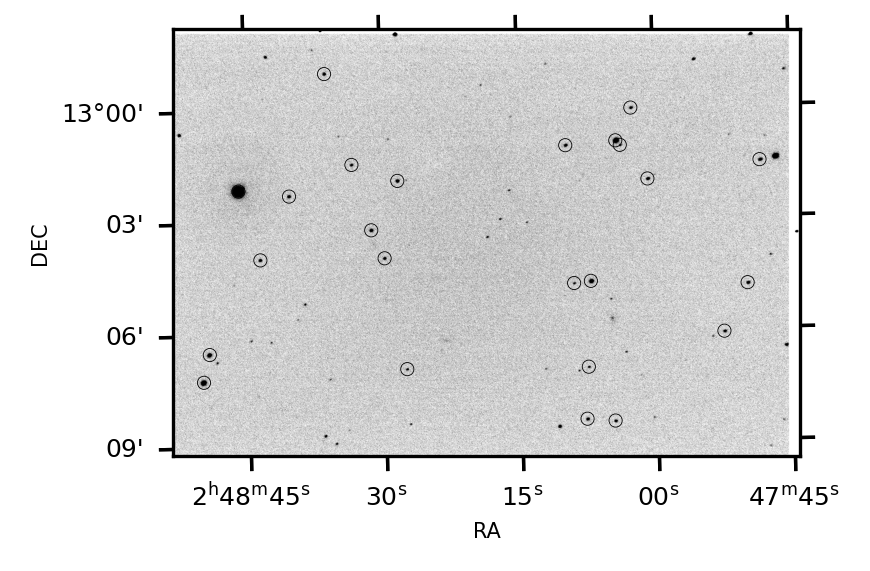

In [13]:
ap =10 # размер апертуры (кружок вокруг звезды)
cf1,cf2 = 0.1,0.5 # определяет окно значений отсчетов, которые будут отрисованы (смотри plt.imshow дальше в этом блоке) 
wcs_based = True# определяет как рисовать систему координат. 
#True - использует WCS и отображаются экваториальные координаты 
#False - отображаются пиксельные координаты 

if wcs_based:
    fig, ax = plt.subplots(figsize=(3.0,3.0), dpi=300, tight_layout=True, subplot_kw={'projection': W})
    ax.coords[0].set_ticklabel(size=6)
    ax.coords[1].set_ticklabel(size=6)
    plt.xlabel('RA', fontsize = 5)
    plt.ylabel('DEC', fontsize=5)
else:
    fig, ax = plt.subplots(figsize=(3.0,3.0), dpi=300)
    ax.xaxis.set_tick_params(labelsize=5)
    ax.yaxis.set_tick_params(labelsize=5)
    plt.xlabel('X, pix', fontsize = 4)
    plt.ylabel('Y, pix', fontsize=4)
#рисуем изображение в серой шкале. Можно поменять cmap='gray' на что-нибудь еще и можно получить всякие более модные отображения
plt.imshow(img, vmin=np.median(img)- cf1*np.std(img) ,
           vmax=np.median(img)  + cf2*np.std(img), origin='lower', cmap=rgray) 
#рисуем метки звезд согласно WCS и координатам звезд из Gaia EDR3
plt.scatter(pixpos[:,0], pixpos[:,1], s=ap, facecolors='none', edgecolors='black', linewidth=0.2)
#автоматически подгоняем рамку 
plt.tight_layout()

In [14]:
# функции для фиттинга изображений звезд и вычисления их пиксельных координат
def gaussian_profile(box,*p):
    Ibkg,Imax,A,B,C,xc,yc = p
    x = np.arange(0, box, 1)
    y = np.arange(0, box, 1)
    x, y = np.meshgrid(x, y)
    r = A*(x-xc)**2+C*(y-yc)**2+B*(x-xc)*(y-yc)
    return np.ravel(Ibkg+Imax*np.exp(-r))

def im_centroiding(I):
    x_c = int(np.shape(I)[0]/2)
    y_c = x_c
    Ib, Im = np.median(I),np.max(I) 
    A = C = 1/5
    B = 0
    return curve_fit(f=gaussian_profile, p0=np.array([Ib,Im,A,B,C,x_c,y_c]),\
                   xdata = np.shape(I)[0],ydata=I.ravel(),maxfev=1000)

In [16]:
RAc_rad = np.radians(RAc)
DECc_rad = np.radians(DECc)
ap = 10
xp,yp = np.array([]),np.array([])
ksi,eta = np.array([]),np.array([])
for k in range(np.size(gmag)):
    x,y = int(pixpos[k,0]),int(pixpos[k,1])
    I = img[y-ap:y+ap,x-ap:x+ap]
    try:
        p, covp = im_centroiding(I)
    except:
        continue
    Ibkg,Imax,A,B,C,xc,yc = p
    if sqrt(covp[5,5])<0.25 and sqrt(covp[6,6])<0.25:
        xp,yp = np.append(xp,x-ap+xc),np.append(yp,y-ap+yc)
        tx, ty = tangential_coordinates(np.deg2rad(ra[k]), np.deg2rad(dec[k]), RAc_rad, DECc_rad)
        ksi,eta = np.append(ksi,tx),np.append(eta,ty)

In [35]:
ksi_deg = np.degrees(ksi)
eta_deg = np.degrees(eta)
C = np.column_stack([np.ones_like(xp), xp,yp ])
Ct = np.transpose(C)
CtCinv  = np.linalg.inv(Ct @ C)

L_ksi = ksi_deg
cx, ax, bx = CtCinv @ Ct @ L_ksi
z = cx, ax, bx

L_eta = eta_deg
cy, ay, by = CtCinv @ Ct @ L_eta

print(f"ksi = {ax}x + {bx}y + {cx}")
print(f"eta = {ax}x + {by}y + {cy}")

def tangential_to_pixel(ksi, eta, ax, bx, cx, ay, by, cy):
    """Ksi, eta to x, y"""
    A = np.array([[ax, bx], 
                  [ay, by]])
    rs = np.array([ksi - cx, eta - cy])
    dx_dy = np.linalg.solve(A, rs)
    return dx_dy[0], dx_dy[1]

x_back, y_back = tangential_to_pixel(ksi_deg, eta_deg, ax, bx, cx, ay, by, cy)

print(f"Mx = {3600*np.sqrt(ax*ax + bx*bx)} arcsec/px, My = {3600*np.sqrt(ay*ay + by*by)} arcsec/px ")

r_ksi = L_ksi - C @ z
r_eta = L_eta - C @ z
print(f"r={r_ksi}")
print(f"r={r_eta}")
len(ksi)

ksi = -0.00013559742545186416x + -2.560809683143709e-06y + 0.1423065412138269
eta = -0.00013559742545186416x + -0.0001355554944906345y + 0.09295429581029302
Mx = 0.48823777524775425 arcsec/px, My = 0.488081713224133 arcsec/px 
r=[ 1.34743669e-05 -8.03127591e-06 -4.20728824e-06  1.25085355e-05
 -1.83318743e-05  1.29982664e-06  1.02576653e-05  2.44855197e-05
  1.35405876e-05  1.77350445e-05 -1.05903638e-04  1.21159051e-05
  1.87905573e-05  3.79574748e-06  1.45377961e-05  1.98409868e-05
 -2.33004848e-05  5.70454207e-06  2.03485607e-07 -1.65049141e-05
  4.14982261e-07 -1.43090760e-06  1.05328624e-05 -1.52802840e-06]
r=[ 0.00628153 -0.00688853  0.01380055  0.01782944  0.08780017  0.04518641
  0.06439653 -0.14806375 -0.06776607 -0.09566938 -0.13561026 -0.11023802
 -0.09526411 -0.07676601 -0.05792341 -0.03954343  0.05767063  0.01946286
 -0.06722523  0.13641987  0.14716568  0.10115162  0.12342121  0.13700321]


24

In [36]:
ksi_model = ax * xp + bx * yp + cx
eta_model = ay * xp + by * yp + cy

r_xi = ksi_deg - ksi_model
r_eta = eta_deg - eta_model

rtrxi = np.sum(r_eta**2)
rtreta = np.sum(r_xi**2)
n = len(xp)
u = 3
f = n - u

sigma0_ksi = rtrxi / f
sigma0_eta = rtreta / f
sigma0_ksi, sigma0_eta = np.sqrt(sigma0_ksi), np.sqrt(sigma0_eta)

final_accuracy_arcsec = (3600 * sigma0_ksi * 1000, 3600 * sigma0_eta * 1000)
print(f"sigma ksi = {final_accuracy_arcsec[0]:.3f} mas, eta = {final_accuracy_arcsec[1]:.3f} mas")

sigma ksi = 40.377 mas, eta = 97.041 mas


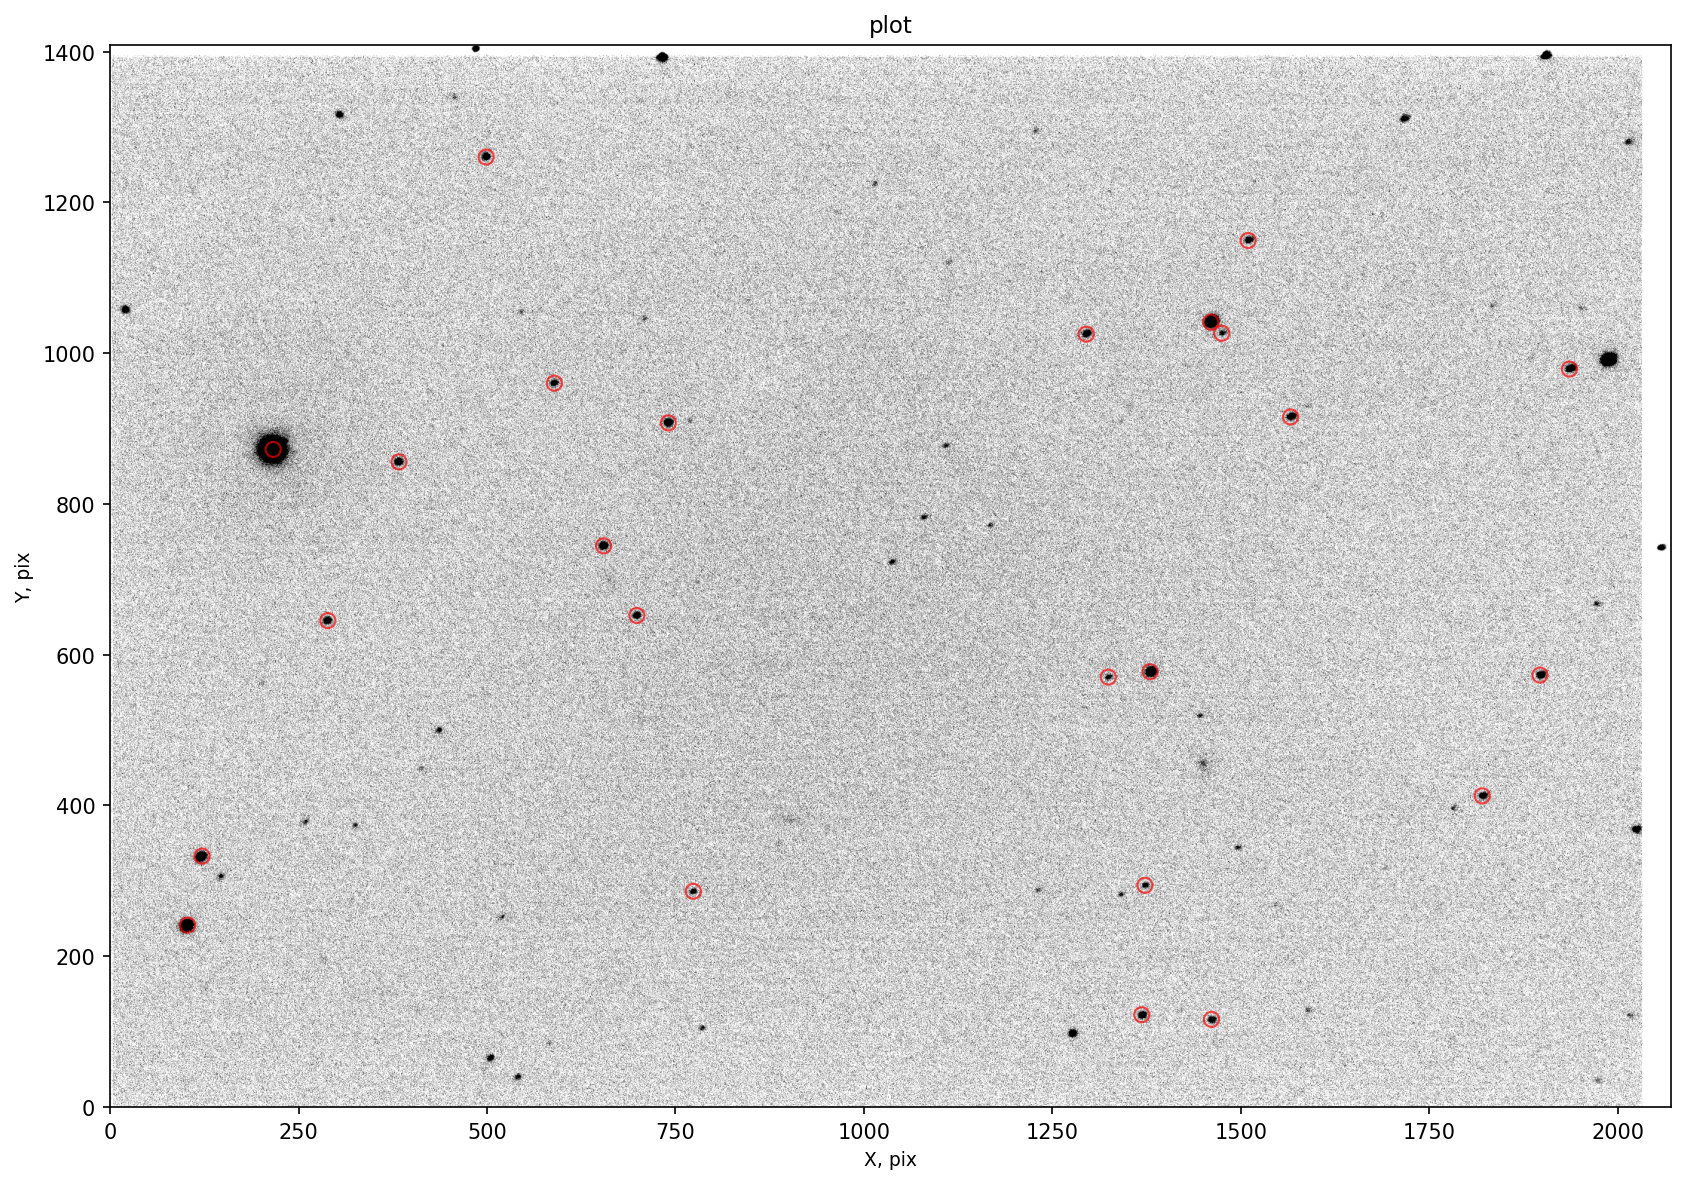

In [33]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

plt.imshow(img, vmin=np.median(img) - cf1*np.std(img), vmax=np.median(img)  + cf2*np.std(img),
           origin='lower', cmap=rgray)

for x, y in zip(x_back, y_back):
    circ = plt.Circle((x, y), 10, color='red', fill=False, linewidth=1, alpha=0.7)
    ax.add_patch(circ)
    
plt.xlabel('X, pix', fontsize=9)
plt.ylabel('Y, pix', fontsize=9)
plt.title(f'plot', 
          fontsize=11)
plt.tight_layout()
plt.show()

In [29]:
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 2072                                                  
NAXIS2  =                 1410                                                  
TARGET  = '7065    '                                                            
DATE-OBS= '2025-10-10T20:56:10.573445'                                          
DATE-END= '2025-10-10T20:56:16.059423'                                          
RA      = '02:48:18.8'                                                          
DEC     = '+13:03:32.0'                                                         
EXPTIME =                  5.0                                                  
FOCUS   =                 7200                                                  
FILTER  = 'R       '        